In [1]:
#!/usr/bin/env python
# coding: utf-8

# In[5]:


#!/usr/bin/env python
# coding: utf-8
"""
B-Pillar CGNN v2 - Improved Demo Code
Synod design deliberation 결과 반영:
  1. Per-block FiLM Generators (4개 독립 generator)
  2. compute_smoothness_loss 수정: 절대 엣지 길이 → 상대 변화량 기반
  3. 그래디언트 클리핑 추가 (IFT 역전파 안정성)
  4. Section continuity loss 추가 (3D 형상 연속성)
  5. 코드 일관성: in_channels=7 명시적 기본값, base_coords 전달 구조화
"""

import matplotlib.pyplot as plt
import numpy as np
import math
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch_geometric.nn import GATv2Conv, LayerNorm
from torch_geometric.data import Data


## ─────────────────────────────────────────────────────────────
## Full Plastic Moment (Differentiable via IFT)
## ─────────────────────────────────────────────────────────────

class ImplicitPNASolver(torch.autograd.Function):
    """
    미분 가능한 소성 중립축(PNA) 및 전소성 모멘트(Mp) 계산기
    Forward : Bisection으로 인장력=압축력 평형점(y_pna) 탐색
    Backward: IFT로 ∂y_pna/∂coords 계산 → chain-rule로 ∂Mp/∂coords 전파
    """

    @staticmethod
    def forward(ctx, coords, t, fy, edge_index, n_iter=30):
        with torch.no_grad():
            y = coords[:, 1]
            t_flat = t.squeeze(-1)
            fy_flat = fy.squeeze(-1)

            y_lo = y.min().clone()
            y_hi = y.max().clone()

            for _ in range(n_iter):
                y_mid = 0.5 * (y_lo + y_hi)
                F_tens = torch.sum(t_flat * fy_flat * torch.clamp(y - y_mid, min=0.0))
                F_comp = torch.sum(t_flat * fy_flat * torch.clamp(y_mid - y, min=0.0))
                if F_tens > F_comp:
                    y_lo = y_mid
                else:
                    y_hi = y_mid

            y_pna = 0.5 * (y_lo + y_hi)

        d = torch.abs(coords[:, 1] - y_pna)
        area = t_flat
        mp_pred = torch.sum(area * fy_flat * d)

        ctx.save_for_backward(coords, t, fy, y_pna.unsqueeze(0), edge_index)
        return mp_pred

    @staticmethod
    def backward(ctx, grad_output):
        coords, t, fy, y_pna_buf, edge_index = ctx.saved_tensors
        y_pna = y_pna_buf.squeeze(0)

        y = coords[:, 1]
        t_flat = t.squeeze(-1)
        fy_flat = fy.squeeze(-1)
        s = torch.sign(y - y_pna)

        dg_dy_pna = -torch.sum(t_flat * fy_flat)
        dg_dy = s * t_flat * fy_flat
        dy_pna_dy = -dg_dy / (dg_dy_pna + 1e-12)

        direct = t_flat * fy_flat * s
        indirect = -torch.sum(t_flat * fy_flat * s) * dy_pna_dy
        dMp_dy = direct + indirect

        grad_coords = torch.zeros_like(coords)
        grad_coords[:, 1] = grad_output * dMp_dy

        return grad_coords, None, None, None, None


def calculate_mpl(coords, t, fy, edge_index):
    return ImplicitPNASolver.apply(coords, t, fy, edge_index)

c:\Users\Youngjae\anaconda3\envs\3.12.12\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
## Model Architecture (v3)
## ─────────────────────────────────────────────────────────────

class FiLMGenerator(nn.Module):
    """target_mp [B, 1] → (gamma, beta) [B, hidden]

    Fix 1: target_mp 정규화 (1,500,000 → 1.5) — 미정규화 시 Linear 가중치에 의해
            gamma/beta ≈ ±3.6M 발생 → h = gamma*h + beta로 hidden state 완전 파괴
    Fix 2: 마지막 레이어 zero-init → 초기 delta_gamma≈0, beta≈0 → identity mapping 보장
    Fix 3: (1 + delta_gamma) 공식 → 초기 gamma=1, 안정적 학습 시작
    """
    MP_SCALE = 1e6  # 1,500,000 → 1.5, 1,000,000 → 1.0

    def __init__(self, hidden_channels: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 64),
            nn.GELU(),
            nn.Linear(64, hidden_channels * 2),
        )
        ## 마지막 레이어 zero-init: 초기 delta_gamma=0, beta=0 → h = (1+0)*h + 0 = h
        nn.init.zeros_(self.net[-1].weight)
        nn.init.zeros_(self.net[-1].bias)

    def forward(self, target_mp):
        ## 정규화: 1,500,000 → 1.5, 1,000,000 → 1.0
        target_mp_norm = target_mp / self.MP_SCALE
        out = self.net(target_mp_norm)
        delta_gamma, beta = torch.chunk(out, 2, dim=-1)
        ## Identity mapping 유도: gamma = 1 + δγ (초기 δγ≈0 → gamma≈1)
        gamma = 1.0 + delta_gamma
        return gamma, beta


class CGDNBlock(nn.Module):
    """GATv2Conv → LayerNorm → FiLM modulation → GELU → Residual  (AdaIN pattern)"""
    def __init__(self, hidden_channels: int, heads: int = 4, edge_dim: int = 4):
        super().__init__()
        assert hidden_channels % heads == 0
        self.conv = GATv2Conv(
            hidden_channels,
            hidden_channels // heads,
            heads=heads,
            edge_dim=edge_dim,
            concat=True,
        )
        self.norm = LayerNorm(hidden_channels)

    def forward(self, h, edge_index, edge_attr, gamma, beta):
        h_res = h
        h = self.conv(h, edge_index, edge_attr)
        h = self.norm(h)              ## Normalize FIRST (AdaIN pattern)
        h = gamma * h + beta          ## FiLM AFTER norm → conditioning preserved
        h = F.gelu(h)
        h = h + h_res
        return h


class CGDN(nn.Module):
    """
    Constraint-aware Graph Deformation Network (v3)

    v3 개선사항:
    - in_channels=8: fix_x, fix_y 분리 (이전 is_fixed 단일 → 축별 독립 고정)
    - fix_x_mask, fix_y_mask: X축/Y축 변위 독립 hard constraint
    - join_pairs: 접합 노드 쌍을 hard projection으로 동시 이동 보장

    입력 노드 특징 (in_channels=8):
        [x, y, fix_x, fix_y, part_id, section_id, t, fy]
        fix_x=1: X좌표 고정, fix_y=1: Y좌표 고정 (독립 설정 가능)
    엣지 특징 (edge_dim=4):
        [길이, 각도, part_id, edge_type]
    조건부 입력:
        target_mp [N, 1] (노드별 목표 전소성 모멘트)
    join_pairs [P, 2]:
        hard joining 쌍 인덱스 — 두 노드의 좌표를 평균으로 hard projection
    """

    def __init__(
        self,
        in_channels: int = 8,
        hidden_channels: int = 128,
        num_layers: int = 4,
        heads: int = 4,
        edge_dim: int = 4,
        max_displacement: float = 50.0,
    ):
        super().__init__()
        self.max_displacement = max_displacement
        self.num_layers = num_layers

        ## 1. Node Encoder
        self.node_encoder = nn.Sequential(
            nn.Linear(in_channels, hidden_channels),
            LayerNorm(hidden_channels),
            nn.GELU(),
        )

        ## 2. Per-block FiLM Generators
        self.film_generators = nn.ModuleList([
            FiLMGenerator(hidden_channels) for _ in range(num_layers)
        ])

        ## 3. GATv2 Message-Passing Blocks
        self.blocks = nn.ModuleList([
            CGDNBlock(hidden_channels, heads=heads, edge_dim=edge_dim)
            for _ in range(num_layers)
        ])

        ## 4. Coordinate Decoder
        self.decoder = nn.Sequential(
            nn.Linear(hidden_channels, 64),
            nn.GELU(),
            nn.Linear(64, 2),
        )

    def forward(self, x, edge_index, edge_attr, target_mp,
                fix_x_mask, fix_y_mask, join_pairs=None):
        """
        x             : [N, in_channels]  노드 특징
        edge_index    : [2, E]
        edge_attr     : [E, edge_dim]
        target_mp     : [N, 1]   노드별 목표 전소성 모멘트
        fix_x_mask    : [N, 1]   X축 고정 Boolean 마스크
        fix_y_mask    : [N, 1]   Y축 고정 Boolean 마스크
        join_pairs    : [P, 2]   hard joining 노드 쌍 인덱스 (없으면 None)
        """
        h = self.node_encoder(x)

        ## Per-block FiLM conditioning
        for i, block in enumerate(self.blocks):
            gamma, beta = self.film_generators[i](target_mp)
            h = block(h, edge_index, edge_attr, gamma, beta)

        delta_coords = self.decoder(h)
        delta_coords = torch.clamp(delta_coords, -self.max_displacement, self.max_displacement)

        ## ── Hard constraint: X축/Y축 독립 고정 ──
        delta_x = delta_coords[:, 0:1] * (~fix_x_mask).float()
        delta_y = delta_coords[:, 1:2] * (~fix_y_mask).float()
        delta_coords = torch.cat([delta_x, delta_y], dim=1)

        new_coords = x[:, :2] + delta_coords

        ## ── Hard joining: 접합 노드 쌍을 좌표 평균으로 projection ──
        ## 두 노드 u, v의 변형 후 좌표를 (coord_u + coord_v) / 2로 강제
        ## gradient는 두 노드에 균등 분배됨 (autograd 정상 동작)
        if join_pairs is not None and join_pairs.shape[0] > 0:
            u_idx = join_pairs[:, 0]
            v_idx = join_pairs[:, 1]
            mid = (new_coords[u_idx] + new_coords[v_idx]) * 0.5  # [P, 2]
            new_coords = new_coords.clone()
            new_coords[u_idx] = mid
            new_coords[v_idx] = mid

        return new_coords, delta_coords



In [3]:
## Loss Functions (v2, unchanged)
## ─────────────────────────────────────────────────────────────

def compute_smoothness_loss(new_coords, base_coords, edge_index, edge_attr):
    """v3: 구조 엣지(edge_type=0) 기준 상대 길이 변화량 최소화"""
    src, dst = edge_index
    edge_type = edge_attr[:, 3]

    ## 구조 엣지만 사용 + 양방향 중복 제거
    mask = (src < dst) & torch.isclose(edge_type, torch.zeros_like(edge_type))
    if not mask.any():
        return torch.tensor(0.0, device=new_coords.device)

    src = src[mask]
    dst = dst[mask]
    new_diff = new_coords[src] - new_coords[dst]
    base_diff = base_coords[src] - base_coords[dst]
    new_len = torch.norm(new_diff, dim=1)
    base_len = torch.norm(base_diff, dim=1)
    rel_change = (new_len - base_len) / torch.clamp(base_len, min=1.0)
    return torch.mean(rel_change ** 2)


def compute_collision_loss(new_coords, part_ids, section_ids, margin=0.5):
    """층별 다중 파트 간섭 방지 (Y좌표 기반)"""
    total_collision_loss = torch.tensor(0.0, device=new_coords.device)
    unique_sections = torch.unique(section_ids)

    for lvl in unique_sections:
        lvl_mask = (section_ids == lvl)
        y_lvl = new_coords[lvl_mask, 1]
        p_lvl = part_ids[lvl_mask]

        mask_1 = (p_lvl == 0)  # Outer
        mask_2 = (p_lvl == 1)  # Reinf
        mask_3 = (p_lvl == 2)  # Inner

        if mask_2.any() and mask_3.any():
            gap_3_2 = torch.clamp(y_lvl[mask_3].max() - y_lvl[mask_2].min() + margin, min=0.0)
            total_collision_loss += gap_3_2 ** 2
            gap_2_1 = torch.clamp(y_lvl[mask_2].max() - y_lvl[mask_1].min() + margin, min=0.0)
            total_collision_loss += gap_2_1 ** 2
        elif mask_3.any() and mask_1.any():
            gap_3_1 = torch.clamp(y_lvl[mask_3].max() - y_lvl[mask_1].min() + margin, min=0.0)
            total_collision_loss += gap_3_1 ** 2

    return total_collision_loss


def compute_collision_loss_v2(base_coords, new_coords, part_ids, section_ids, margin=0.5, 
                              width_axis=0, thickness_axis=1, search_radius=5.0):
    """
    초기 형상(Base Coords) 기준으로 파트 간 대응 쌍을 찾고, 
    변형된 형상(New Coords) 기준으로 간섭을 검사하는 완벽한 로직.
    """
    total_collision_loss = torch.tensor(0.0, device=new_coords.device)
    unique_sections = torch.unique(section_ids)

    for lvl in unique_sections:
        lvl_mask = (section_ids == lvl)
        
        # Base와 New 좌표 모두 마스킹 추출
        base_lvl = base_coords[lvl_mask]
        new_lvl = new_coords[lvl_mask]
        p_lvl = part_ids[lvl_mask]

        mask_outer = (p_lvl == 0)  # Outer (그릇 위쪽)
        mask_reinf = (p_lvl == 1)  # Reinf (그릇 중간)
        mask_inner = (p_lvl == 2)  # Inner (그릇 아래쪽)
        
        def calc_lagrangian_interference(b_top, b_bot, n_top, n_bot):
            if len(b_top) == 0 or len(b_bot) == 0:
                return torch.tensor(0.0, device=new_coords.device)
            
            # 1. [핵심 수정] 대응 쌍(Neighbor) 탐색은 '초기 좌표(base_coords)' 기준
            # 원래 설계에서 폭 방향으로 가까웠던 노드들만 짝을 지어줌
            w_top_base = b_top[:, width_axis].unsqueeze(1)
            w_bot_base = b_bot[:, width_axis].unsqueeze(0)
            
            w_dist_base = torch.abs(w_top_base - w_bot_base)
            neighbor_mask = (w_dist_base < search_radius)
            
            # 2. 간섭량(Violation) 계산은 '변형 후 좌표(new_coords)' 기준
            # 짝지어진 노드들이 현재 어떻게 변형되었는지 확인
            t_top_new = n_top[:, thickness_axis].unsqueeze(1)
            t_bot_new = n_bot[:, thickness_axis].unsqueeze(0)
            
            # 위반 조건: Top의 Y >= Bottom의 Y + margin
            violation = torch.clamp(margin - (t_top_new - t_bot_new), min=0.0)
            
            # 3. 초기 상태에서 가까웠던(neighbor_mask) 노드들의 현재 간섭량만 추출
            loss = torch.sum((violation ** 2) * neighbor_mask)
            return loss

        if mask_outer.any() and mask_reinf.any():
            total_collision_loss += calc_lagrangian_interference(
                base_lvl[mask_outer], base_lvl[mask_reinf],
                new_lvl[mask_outer], new_lvl[mask_reinf]
            )
            
        if mask_reinf.any() and mask_inner.any():
            total_collision_loss += calc_lagrangian_interference(
                base_lvl[mask_reinf], base_lvl[mask_inner],
                new_lvl[mask_reinf], new_lvl[mask_inner]
            )

    return total_collision_loss


def compute_section_continuity_loss(new_coords, base_coords, section_ids, part_ids):
    """인접 섹션 간 같은 파트의 평균 변위 차이 최소화"""
    loss = torch.tensor(0.0, device=new_coords.device)
    delta = new_coords - base_coords

    unique_sections = torch.unique(section_ids)
    unique_parts = torch.unique(part_ids)

    for i in range(len(unique_sections) - 1):
        sec_a = unique_sections[i]
        sec_b = unique_sections[i + 1]

        for part in unique_parts:
            mask_a = (section_ids == sec_a) & (part_ids == part)
            mask_b = (section_ids == sec_b) & (part_ids == part)

            if mask_a.any() and mask_b.any():
                mean_delta_a = delta[mask_a].mean(dim=0)
                mean_delta_b = delta[mask_b].mean(dim=0)
                loss += torch.sum((mean_delta_b - mean_delta_a) ** 2)
    return loss


def compute_mass_loss(new_coords, t, edge_index, edge_attr, target_area=None):
    """총 질량(또는 목표 질량 오차)을 계산

    - 기본 동작: 엣지 길이 * 두께 합산 → 면적(질량)
    - ``target_area``가 주어지면 상대 오차 제곱을 반환하여
      손실로 사용할 수 있음.
    """

    src, dst = edge_index
    edge_type = edge_attr[:, 3]

    ## 구조 엣지(edge_type=0)만 질량 근사에 사용 + 양방향 중복 제거
    mask = (src < dst) & torch.isclose(edge_type, torch.zeros_like(edge_type))
    src = src[mask]
    dst = dst[mask]

    seg_len = torch.norm(new_coords[src] - new_coords[dst], dim=1)
    t_src = t[src].squeeze(-1)
    area = torch.sum(seg_len * t_src)
    return area, torch.abs(area - target_area) if target_area is not None else area


def compute_boundary_constraints_loss(new_coords, section_ids, bound, keepout=None):
    """
    섹션(단면)별로 독립적인 허용 범위(Bounds)와 진입 금지 구역(Keep-out Zone)을 강제하는 Loss 함수.
    
    - section_ids: 각 노드의 섹션 ID가 담긴 1D 텐서
    - bound: {섹션ID: (x_min, x_max, y_min, y_max)} 형태의 딕셔너리
    - keepout: {섹션ID: (x_min, x_max, y_min, y_max)} 형태의 딕셔너리 (없는 섹션은 생략 가능)
    """
    total_bounds_loss = torch.tensor(0.0, device=new_coords.device)
    unique_sections = torch.unique(section_ids)
    
    for lvl in unique_sections:
        lvl_idx = int(lvl.item())
        mask = (section_ids == lvl)
        
        x = new_coords[mask, 0]
        y = new_coords[mask, 1]
        
        # ---------------------------------------------------------
        # 1. Outer Bounds Loss (해당 섹션에 bounds 설정이 있는 경우)
        # ---------------------------------------------------------
        if bound is not None and lvl_idx in bound:
            b_xmin, b_xmax, b_ymin, b_ymax = bound[lvl_idx]

            x_out_min = F.relu(b_xmin - x)
            x_out_max = F.relu(x - b_xmax)
            y_out_min = F.relu(b_ymin - y)
            y_out_max = F.relu(y - b_ymax)
            
            total_bounds_loss += torch.sum(x_out_min**2 + x_out_max**2 + y_out_min**2 + y_out_max**2)
            
        # # ---------------------------------------------------------
        # # 2. Keep-out Zone Loss (해당 섹션에 keepout 설정이 있는 경우)
        # # ---------------------------------------------------------
        # if keepout is not None and lvl_idx in keepout:
        #     k_xmin, k_xmax, k_ymin, k_ymax = keepout[lvl_idx]
            
        #     in_x = (x > k_xmin) & (x < k_xmax)
        #     in_y = (y > k_ymin) & (y < k_ymax)
        #     in_keepout = in_x & in_y
            
        #     if in_keepout.any():
        #         x_in = x[in_keepout]
        #         y_in = y[in_keepout]
                
        #         dist_left = x_in - k_xmin
        #         dist_right = k_xmax - x_in
        #         dist_bottom = y_in - k_ymin
        #         dist_top = k_ymax - y_in
                
        #         dists = torch.stack([dist_left, dist_right, dist_bottom, dist_top], dim=1)
        #         min_dists, _ = torch.min(dists, dim=1)
                
        #         total_bounds_loss += torch.sum(min_dists**2)
                
    return total_bounds_loss


def compute_repulsive_keepout_loss(new_coords, section_ids, keepout, height_multiplier=1.0):
    """
    가상의 자석(척력)을 이용해 노드를 부드럽게 밀어내는 Loss.
    - height_multiplier: 언덕의 높이 (에폭이 지날수록 증가시킴)
    """
    total_repulsive_loss = torch.tensor(0.0, device=new_coords.device)
    
    if keepout is None:
        return total_repulsive_loss

    unique_sections = torch.unique(section_ids)
    
    for lvl in unique_sections:
        lvl_idx = int(lvl.item())
        if lvl_idx in keepout:
            mask = (section_ids == lvl)
            x = new_coords[mask, 0]
            y = new_coords[mask, 1]

            for kz in keepout[lvl_idx]:
                k_xmin, k_xmax, k_ymin, k_ymax = kz

                # 언덕의 중심점과 영향력 반경 설정 (0으로 나누기 방지)
                center_x = (k_xmin + k_xmax) / 2.0
                center_y = (k_ymin + k_ymax) / 2.0
                radius_x = max((k_xmax - k_xmin) / 2.0, 1e-6)
                radius_y = max((k_ymax - k_ymin) / 2.0, 1e-6)

                # 박스 내부에 들어온(또는 근접한) 노드들만 필터링
                in_box = (x > k_xmin) & (x < k_xmax) & (y > k_ymin) & (y < k_ymax)

                if in_box.any():
                    x_in = x[in_box]
                    y_in = y[in_box]

                    # X, Y축 각각의 정규화 거리 (중앙=0.0, 경계=1.0 미만)
                    dist_x = ((x_in - center_x) / radius_x) ** 2
                    dist_y = ((y_in - center_y) / radius_y) ** 2

                    # 거리가 0(중앙)일 때 최대값 1.0을 가지고, 멀어질수록 0에 수렴
                    repulsion = torch.exp(-dist_x - dist_y)

                    # 커리큘럼 높이를 곱해 최종 합산
                    total_repulsive_loss += torch.sum(repulsion) * height_multiplier

    return total_repulsive_loss

In [4]:
## Training Step
## ─────────────────────────────────────────────────────────────

def get_curriculum_weights(epoch, total_epochs, warmup_ratio=0.3):
    """
    에폭 진행도에 따라 손실 함수의 가중치 multiplier(0→1)를 반환합니다.
    Phase 1 (0 ~ warmup_ratio * total_epochs):
        형상/경계조건 안정화 우선
    Phase 2 (warmup_ratio ~ 1.0):
        0→1로 선형 증가
    """

    phase1_epochs = int(total_epochs * warmup_ratio)
    denom = max(total_epochs - phase1_epochs, 1)  # div-by-zero 방지

    if epoch < phase1_epochs:
        progress = 0.0
    else:
        progress = (epoch - phase1_epochs) / denom  # 0.0 → 1.0

    s_phys       = 1.0
    s_smooth     = progress
    s_mass       = progress
    s_collision  = 1.0
    s_fix        = 1.0
    s_continuity = 1.0
    s_bounds     = 1.0
    s_keepout    = progress
    return s_phys, s_smooth, s_mass, s_collision, s_fix, s_continuity, s_bounds, s_keepout


def train_step(model, data, optimizer, target_mps, target_area, bounds, keepout,
               epoch, max_epochs, max_grad_norm=1.0, weights=None, warmup_ratio=0.3):
    """
    v3 변경사항:
    - 노드 피처 8열: [x, y, fix_x, fix_y, part_id, section_id, t, fy]
    - fix_x_mask, fix_y_mask 분리 추출
    - join_pairs 전달 (hard joining 적용)
    - 열 인덱스 전체 업데이트
    - target_area: 전체(또는 섹션별) 목표 질량을 지정하면
      compute_mass_loss에서 오차 기반 손실을 계산함
    """
    model.train()
    optimizer.zero_grad()

    x          = data.x                          ## [N, 8]
    edge_index = data.edge_index                 ## [2, E]
    edge_attr  = data.edge_attr                  ## [E, 4]
    join_pairs = data.join_pairs if hasattr(data, 'join_pairs') else None
    base_coords = data.x[:, :2].detach()         ## [N, 2] 초기 좌표

    ## ── 노드 피처 추출 (v3: 8열 기준) ──
    fix_x_mask  = x[:, 2].bool().unsqueeze(1)    ## X축 고정 마스크
    fix_y_mask  = x[:, 3].bool().unsqueeze(1)    ## Y축 고정 마스크
    part_ids    = x[:, 4]
    section_ids = x[:, 5]
    t           = x[:, 6].unsqueeze(1)
    fy          = x[:, 7].unsqueeze(1)

    unique_sections = torch.unique(section_ids)

    ## ── 노드별 목표 Mp 텐서 생성 ──
    target_mp_node = torch.zeros((x.shape[0], 1), dtype=torch.float32, device=x.device)
    for section in unique_sections:
        section_mask = (section_ids == section)
        section_int = int(section.item())
        target_mp_node[section_mask] = target_mps[section_int]

    ## ── GNN Forward Pass ──
    new_coords, delta_coords = model(
        x, edge_index, edge_attr, target_mp_node,
        fix_x_mask, fix_y_mask, join_pairs
    )

    ## ── 층별 물리 손실 (L_phys) ──
    l_phys_total = torch.tensor(0.0, device=x.device)
    pred_mp_sections = []

    for section in unique_sections:
        section_mask = (section_ids == section)
        coords_section = new_coords[section_mask]
        t_section = t[section_mask]
        fy_section = fy[section_mask]

        pred_mp_section = calculate_mpl(coords_section, t_section, fy_section, None)
        section_int = int(section.item())
        target_mp_section = torch.tensor(target_mps[section_int], dtype=torch.float32, device=x.device)

        l_phys_section = ((pred_mp_section - target_mp_section) / target_mp_section) ** 2
        l_phys_section = (pred_mp_section - target_mp_section) ** 2
        # l_phys_section = abs(pred_mp_section - target_mp_section)
        l_phys_total += l_phys_section.squeeze()
        pred_mp_sections.append(pred_mp_section.item())

    num_sections = len(unique_sections)
    l_phys_total = torch.sqrt(l_phys_total) / num_sections
    pred_mp_sections = np.array(pred_mp_sections)

    ## ── 커리큘럼 가중치 (0→1 multiplier) ──
    s_phys, s_smooth, s_mass, s_collision, s_fix, s_continuity, s_bounds, s_keepout = 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0
    (s_phys, s_smooth, s_mass, s_collision, s_fix, s_continuity, s_bounds, s_keepout
     ) = get_curriculum_weights(epoch, max_epochs, warmup_ratio=warmup_ratio)

    ## ── 다목적 손실 계산 ──
    l_smooth     = compute_smoothness_loss(new_coords, base_coords, edge_index, edge_attr)
    area, l_mass = compute_mass_loss(new_coords, t, edge_index, edge_attr, target_area)
    l_collision  = compute_collision_loss(new_coords, part_ids, section_ids)
    l_continuity = compute_section_continuity_loss(new_coords, base_coords, section_ids, part_ids)
    l_bounds = compute_boundary_constraints_loss(new_coords, section_ids, bounds)
    l_keepout = compute_repulsive_keepout_loss(new_coords, section_ids, keepout, height_multiplier=s_keepout)
    
    ## ── 고정점 손실: fix_x 또는 fix_y가 있는 노드의 delta 크기 ──
    any_fixed = (fix_x_mask | fix_y_mask).squeeze()
    if any_fixed.any():
        l_fix = torch.sum(torch.norm(delta_coords[any_fixed], dim=1))
    else:
        l_fix = torch.tensor(0.0, device=x.device)

    ## ── Total Loss ──
    loss = (weights['w_phys']       * l_phys_total * s_phys
          + weights['w_smooth']     * l_smooth     * s_smooth
          + weights['w_mass']       * l_mass       * s_mass
          + weights['w_collision']  * l_collision  * s_collision
          + weights['w_fix']        * l_fix        * s_fix
          + weights['w_continuity'] * l_continuity * s_continuity
          + weights['w_bounds']     * l_bounds     * s_bounds
          + weights['w_keepout']    * l_keepout    * s_keepout
          )

    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=max_grad_norm)
    optimizer.step()

    return {
        "loss":          loss.item(),
        "pred_mp":       pred_mp_sections,
        "l_phys":        l_phys_total.item(),
        "l_smooth":      l_smooth.item(),
        "initial_area":  area.item() if epoch == 0 else None,  # 첫 에폭에서 초기 면적 기록
        "area":          area.item(),
        "l_mass":        l_mass.item(),
        "l_collision":   l_collision.item(),
        "l_fix":         l_fix.item() if isinstance(l_fix, torch.Tensor) else l_fix,
        "l_continuity":  l_continuity.item(),
        "l_bounds":     l_bounds.item(),
        "l_keepout":    l_keepout.item(),
        "new_coords":    new_coords.detach(),
    }

def training(model, data, optimizer, target_mps, target_area, bounds, keepout, max_epochs, 
             max_grad_norm=1.0, weights=None, warmup_ratio=0.3):

    loss_hist         = []
    l_phys_hist       = []
    l_smooth_hist     = []
    initial_area      = None
    area_hist         = []
    l_mass_hist       = []
    l_collision_hist  = []
    l_fix_hist        = []
    l_continuity_hist = []
    l_bounds_hist    = []
    l_keepout_hist   = []

    for epoch in range(max_epochs):

        info = train_step(model, data, optimizer, target_mps, target_area, bounds, keepout,
                          epoch, max_epochs, weights=weights,warmup_ratio=warmup_ratio)

        loss_hist.append(info['loss'])
        l_phys_hist.append(info['l_phys'])
        l_smooth_hist.append(info['l_smooth'])
        area_hist.append(info['area'])
        l_mass_hist.append(info['l_mass'])
        l_collision_hist.append(info['l_collision'])
        l_fix_hist.append(info['l_fix'])
        l_continuity_hist.append(info['l_continuity'])
        l_bounds_hist.append(info['l_bounds'])
        l_keepout_hist.append(info['l_keepout'])

        if (epoch+1) % 100 == 0:
            target_mp_str = ', '.join(f'{target_mps[k]:.0f}' for k in sorted(target_mps))
            print(
                f"Epoch {epoch:03d} | "
                f"Loss: {info['loss']:.4f} | \n    "
                f"Mp: {info['pred_mp']} / [{target_mp_str}] | \n    "
                f"Phys: {info['l_phys']:.4f}  "
                f"Smth: {info['l_smooth']:.4f}  "
                f"area: {info['area']:.4f} / {target_area:.4f}  "
                f"Mass: {info['l_mass']:.4f}  \n    "
                f"Coll: {info['l_collision']:.4f}  "
                f"Fix: {info['l_fix']:.4f}  "
                f"Cont: {info['l_continuity']:.4f}  "
                f"bounds: {info['l_bounds']:.4f}  "
                f"Keep: {info['l_keepout']:.4f}  "
            )

        if epoch == 0:
            initial_area = info['area']

    return (loss_hist, info, l_phys_hist, l_smooth_hist, initial_area, area_hist, l_mass_hist,
        l_collision_hist, l_fix_hist, l_continuity_hist, l_bounds_hist, l_keepout_hist)


Nodes: torch.Size([570, 8]) | Edges: torch.Size([2, 2342]) | Edge Features: torch.Size([2342, 4]) | Join Pairs: torch.Size([0])


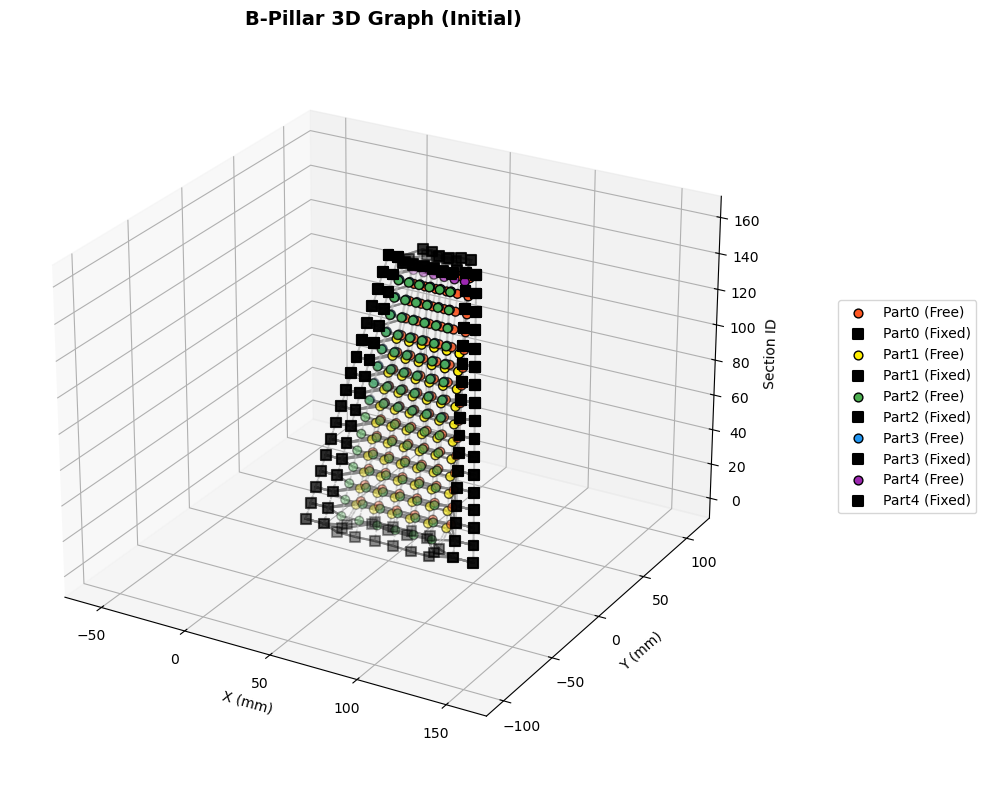

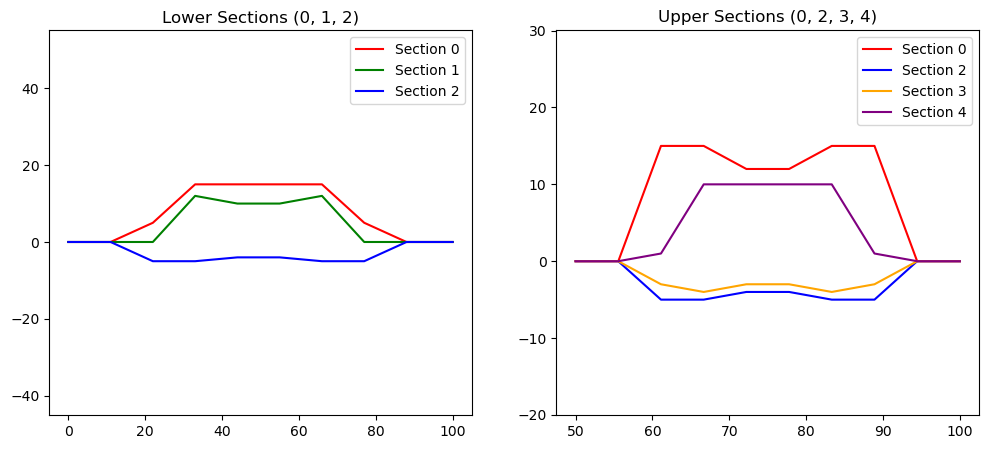

In [ ]:
## Data Construction (v3: 8-feature nodes + join_pairs)
## ─────────────────────────────────────────────────────────────
"""
B-Pillar 3x3 구조:
    section 16 (17층): part 0, 4, 3, 2
    section 15 (16층): part 0, 4, 3, 2
    section 14 (15층): part 0,    3, 2
    section 13 (14층): part 0,    3, 2
    section 12 (13층): part 0,    3, 2
    section 11 (12층): part 0, 1, 3, 2
    section 10 (11층): part 0, 1, 3, 2
    section 9  (10층): part 0, 1, 3, 2
    section 8  (9층):  part 0, 1, 3, 2
    section 7  (8층):  part 0, 1,    2
    section 6  (7층):  part 0, 1,    2
    section 5  (6층):  part 0, 1,    2
    section 4  (5층):  part 0, 1,    2
    section 3  (4층):  part 0, 1,    2
    section 2  (3층):  part 0, 1,    2
    section 1  (2층):  part 0, 1,    2
    section 0  (1층):  part 0, 1,    2

노드 피처 (8열):
  [x, y, fix_x, fix_y, part_id, section_id, t, fy]
  fix_x=1: X축 고정, fix_y=1: Y축 고정 (독립 설정)

경계조건:
  - is_fixed(xy 동시): 양 끝 플랜지 노드 i=0,1,8,9 → fix_x=fix_y=1
  - section 0,2의 Outer 중간 노드 i=3,6 → fix_x=fix_y=1

join_pairs:
  - 플랜지 위치(i=0,9)에서 파트 간 hard joining
  - 실제 용접/볼트 접합 표현 (동시이동 hard 보장)
"""
parts_in_sections = {
    0:  [0, 1, 2],
    1:  [0, 1, 2],
    2:  [0, 1, 2],
    3:  [0, 1, 2],
    4:  [0, 1, 2],
    5:  [0, 1, 2],
    6:  [0, 1, 2],
    7:  [0, 1, 2],
    8:  [0, 1, 2, 3],
    9:  [0, 1, 2, 3],
    10: [0, 1, 2, 3],
    11: [0, 1, 2, 3],
    12: [0, 2, 3],
    13: [0, 2, 3],
    14: [0, 2, 3],
    15: [0, 2, 3, 4],
    16: [0, 2, 3, 4],
}

lower_section = {
    0: [[0, 0], [11, 0], [22, 5], [33, 15], [44, 15], [55, 15], [66, 15], [77, 5], [88, 0], [100, 0]],
    1: [[0, 0], [11, 0], [22, 0], [33, 12], [44, 10], [55, 10], [66, 12], [77, 0], [88, 0], [100, 0]],
    2: [[0, 0], [11, 0], [22, -5], [33, -5], [44, -4], [55, -4], [66, -5], [77, -5], [88, 0], [100, 0]],
}

upper_section = {
    0: [[50, 0], [55.56, 0], [61.11, 15], [66.67, 15], [72.22, 12], [77.78, 12], [83.33, 15], [88.89, 15], [94.44, 0], [100, 0]],
    4: [[50, 0], [55.55, 0], [61.11, 1],  [66.67, 10], [72.22, 10], [77.78, 10], [83.33, 10], [88.89, 1], [94.44, 0], [100, 0]],
    3: [[50, 0], [55.55, 0], [61.11, -3], [66.67, -4], [72.22, -3],[77.78, -3],[83.33, -4], [88.89, -3],[94.44, 0], [100, 0]],
    2: [[50, 0], [55.55, 0], [61.11, -5], [66.67, -5], [72.22, -4],[77.78, -4],[83.33, -5], [88.89, -5],[94.44, 0], [100, 0]],
    }

num_sections = len(parts_in_sections)
num_nodes = 10
num_nodes_total = sum(len(parts)*num_nodes for parts in parts_in_sections.values())

x = torch.zeros((num_nodes_total, 8), dtype=torch.float32)
node_registry = {}
current_idx = 0
for section in range(num_sections):
    parts_in_section = parts_in_sections[section]

    for part in parts_in_section:
        for i in range(num_nodes):
            x_coord = i * (100.0 - (50/(num_sections-1))*section) / 9.0 + (50/(num_sections-1))*section  # 기본 X 좌표 (0~100) + 섹션별 약간의 X 오프셋
            if i in [0, 1, 8, 9]:
                y_coord = 0.0
            else:
                if part == 2: y_coord = -5.0
                elif part == 3: y_coord = -4.0
                elif part == 1 or part == 4: y_coord = 10.0
                elif part == 0: y_coord = 15.0
                else: y_coord = 0.0

            ## 플랜지 위치(i=0,1,8,9)에서 모든 파트 고정
            fix_x = 1.0 if (i in [0, 1, 8, 9]) else 0.0
            fix_y = 1.0 if (i in [0, 1, 8, 9]) else 0.0

            ## Upper and lower section
            if section == 16:
                x_coord = upper_section[part][i][0]
                y_coord = upper_section[part][i][1]
                fix_x = 1.0
                fix_y = 1.0
            elif section == 0:
                x_coord = lower_section[part][i][0]
                y_coord = lower_section[part][i][1]
                fix_x = 1.0
                fix_y = 1.0

            t_val  = 1.5 if part != 1 else 2.0
            fy_val = 1500.0 if part != 2 else 1200.0

            ## [x, y, fix_x, fix_y, part_id, section_id, t, fy]
            x[current_idx] = torch.tensor([x_coord, y_coord, fix_x, fix_y,
                                            float(part), float(section), t_val, fy_val])
            node_registry[(section, part, i)] = current_idx
            current_idx += 1

## ── Edge Construction ──
src_list, dst_list = [], []
edge_attr_list = []

def add_edge(u, v, part_id, edge_type):
    src_list.extend([u, v])
    dst_list.extend([v, u])
    dx = x[v, 0] - x[u, 0]
    dy = x[v, 1] - x[u, 1]
    length = math.sqrt(dx**2 + dy**2)
    angle = math.atan2(dy, dx)
    edge_attr_list.extend([[length, angle, part_id, edge_type],
                            [length, -angle, part_id, edge_type]])

# Intra-section (횡방향)
for section in range(num_sections):
    parts = parts_in_sections[section]
    for part in parts:
        for i in range(num_nodes - 1):
            u = node_registry[(section, part, i)]
            v = node_registry[(section, part, i+1)]
            add_edge(u, v, part_id=part, edge_type=0.0)

# Inter-section (종방향: 3D 연속성)
for section in range(num_sections - 1):
    next_section = section + 1
    # 현재 층과 다음 층에 공통으로 존재하는 파트만 추출 (교집합)
    common_parts = set(parts_in_sections[section]).intersection(parts_in_sections[next_section])
    for part in common_parts:
        for i in range(num_nodes):
            u = node_registry[(section, part, i)]
            v = node_registry[(next_section, part, i)]
            add_edge(u, v, part_id=part, edge_type=1.0)

# Flange binding (파트 끝점 결합)
for section in range(num_sections):
    parts = parts_in_sections[section]
    for i in [0, 9]:  # 플랜지 위치
        # 해당 층에 존재하는 파트들끼리 서로 모두 묶어줌 (완전연결/클릭)
        for p1_idx in range(len(parts)):
            for p2_idx in range(p1_idx + 1, len(parts)):
                p1 = parts[p1_idx]
                p2 = parts[p2_idx]
                u = node_registry[(section, p1, i)]
                v = node_registry[(section, p2, i)]
                add_edge(u, v, part_id=0.0, edge_type=2.0)

# Part binding (메시지 패싱 엣지 전체 연결, edge_type=2; hard joining은 끝단만)
join_pairs_list = []
# for section in [0, 1, 2]:
#     for i in range(num_nodes):
#         u0 = node_registry[(section, 0, i)]
#         u2 = node_registry[(section, 2, i)]
#         if section in [0, 1]:
#             u1 = node_registry[(section, 1, i)]

#         # hard joining: 실제 접합 위치(끝단)만 강제
#         if i in [3, 4, 5, 6]:
#             # join_pairs_list.append([u0, u2])
#             if section in [0, 1]:
#                 join_pairs_list.append([u0, u1])
#                 # join_pairs_list.append([u1, u2])

edge_index = torch.tensor([src_list, dst_list], dtype=torch.long)
edge_attr  = torch.tensor(edge_attr_list, dtype=torch.float32)
join_pairs = torch.tensor(join_pairs_list, dtype=torch.long)

## ── Bound & Keep-out Zone 설정 ──
bounds = {0: (0.0, 100.0, -10.0, 20.0),
          1: (0.0, 100.0, -10.0, 20.0),
          2: (0.0, 100.0, -10.0, 20.0),
          3: (0.0, 100.0, -10.0, 20.0),
          4: (0.0, 100.0, -10.0, 20.0),
          5: (0.0, 100.0, -10.0, 20.0),
          6: (0.0, 100.0, -10.0, 20.0),
          7: (0.0, 100.0, -10.0, 20.0),
          8: (0.0, 100.0, -10.0, 20.0),
          9: (0.0, 100.0, -10.0, 20.0),
          10: (0.0, 100.0, -10.0, 20.0),
          11: (0.0, 100.0, -10.0, 20.0),
          12: (0.0, 100.0, -10.0, 20.0),
          13: (0.0, 100.0, -10.0, 20.0),
          14: (0.0, 100.0, -10.0, 20.0),
          15: (0.0, 100.0, -10.0, 20.0),
          16: (0.0, 100.0, -10.0, 20.0),
          }
keepout = {0: [(60.0, 70.0, 3.0, 8.0), (40.0, 60.0, 12.0, 14.0)],
           1: [(60.0, 70.0, 3.0, 8.0), (40.0, 60.0, 12.0, 14.0)],
           2: [(60.0, 70.0, 3.0, 8.0), (40.0, 60.0, 12.0, 14.0)],
           3: [(60.0, 70.0, 3.0, 8.0), (40.0, 60.0, 12.0, 14.0)],
           4: [(60.0, 70.0, 3.0, 8.0), (40.0, 60.0, 12.0, 14.0)],
           5: [(60.0, 70.0, 3.0, 8.0), (40.0, 60.0, 12.0, 14.0)],
           6: [(60.0, 70.0, 3.0, 8.0), (40.0, 60.0, 12.0, 14.0)],
           7: [(60.0, 70.0, 3.0, 8.0), (40.0, 60.0, 12.0, 14.0)],
           8: [(60.0, 70.0, 3.0, 8.0), (40.0, 60.0, 12.0, 14.0)],
           9: [(60.0, 70.0, 3.0, 8.0), (40.0, 60.0, 12.0, 14.0)],
           10: [(60.0, 70.0, 3.0, 8.0), (40.0, 60.0, 12.0, 14.0)],
           11: [(60.0, 70.0, 3.0, 8.0), (40.0, 60.0, 12.0, 14.0)],
           12: [(60.0, 70.0, 3.0, 8.0), (40.0, 60.0, 12.0, 14.0)],
           13: [(60.0, 70.0, 3.0, 8.0), (40.0, 60.0, 12.0, 14.0)],
           14: [(60.0, 70.0, 3.0, 8.0), (40.0, 60.0, 12.0, 14.0)],
           15: [(60.0, 70.0, 3.0, 8.0), (40.0, 60.0, 12.0, 14.0)],
           16: [(60.0, 70.0, 3.0, 8.0), (40.0, 60.0, 12.0, 14.0)],
           }

print(f"Nodes: {x.shape} | Edges: {edge_index.shape} | "
      f"Edge Features: {edge_attr.shape} | Join Pairs: {join_pairs.shape}")


## ─────────────────────────────────────────────────────────────
## 3D Visualization (v3: 열 인덱스 업데이트)
## ─────────────────────────────────────────────────────────────

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

x_np  = x.cpu().numpy()
ei_np = edge_index.cpu().numpy()
ea_np = edge_attr.cpu().numpy()

color_map = {0: '#FF5722', 1: '#FFEE00', 2: '#4CAF50', 3: '#2196F3', 4: '#9C27B0'} 

for i in range(ei_np.shape[1]):
    u = ei_np[0, i]
    v = ei_np[1, i]
    e_type = ea_np[i, 3]
    xs = [x_np[u, 0], x_np[v, 0]]
    ys = [x_np[u, 1], x_np[v, 1]]
    zs = [x_np[u, 5]*10, x_np[v, 5]*10]
    if e_type == 0.0:
        ax.plot(xs, ys, zs, color='#888888', linestyle='-',  linewidth=1.5, alpha=0.9)
    elif e_type == 1.0:
        ax.plot(xs, ys, zs, color='#BBBBBB', linestyle='--', linewidth=1.2, alpha=0.6)
    elif e_type == 2.0:
        ax.plot(xs, ys, zs, color='red',     linestyle=':',  linewidth=3.0, alpha=0.9)

for part_id in color_map.keys():
    ## v3: part_id → col 4, fix_x → col 2, fix_y → col 3
    is_any_fixed = (x_np[:, 2] > 0) | (x_np[:, 3] > 0)
    mask       = (x_np[:, 4] == part_id) & ~is_any_fixed
    mask_fixed = (x_np[:, 4] == part_id) &  is_any_fixed
    part_name = {0: 'Part0', 1: 'Part1', 2: 'Part2', 3: 'Part3', 4: 'Part4', 5: 'Part5'}.get(part_id, f'Part{part_id}')
    ax.scatter(x_np[mask, 0], x_np[mask, 1], x_np[mask, 5]*10,
               c=color_map[part_id], marker='o', s=40, edgecolors='k', label=f'{part_name} (Free)')
    if mask_fixed.any():
        # 내부 색상을 검은색으로, 테두리를 파트 색상으로 반전 (가시성 매우 좋음)
        ax.scatter(x_np[mask_fixed, 0], x_np[mask_fixed, 1], x_np[mask_fixed, 5]*10,
                   c='black', marker='s', s=50, linewidths=1.5,
                   label=f'{part_name} (Fixed)')

ax.set_xlabel('X (mm)')
ax.set_ylabel('Y (mm)')
ax.set_zlabel('Section ID')
ax.set_title('B-Pillar 3D Graph (Initial)', fontsize=14, fontweight='bold')
# ax.set_zticks(range(num_sections)*10)
ax.set_xlim(-10, 110)
ax.set_ylim(-15, 25)
# ax.set_zlim(-0.5, 2.5)
ax.view_init(elev=25, azim=-60)
handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys(), loc='center left', bbox_to_anchor=(1.1, 0.5))
plt.axis('equal')
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(np.array(lower_section[0])[:,0], np.array(lower_section[0])[:,1], label='Section 0', color='red')
plt.plot(np.array(lower_section[1])[:,0], np.array(lower_section[1])[:,1], label='Section 1', color='green')
plt.plot(np.array(lower_section[2])[:,0], np.array(lower_section[2])[:,1], label='Section 2', color='blue')
plt.title('Lower Sections (0, 1, 2)')
plt.axis('equal')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(np.array(upper_section[0])[:,0], np.array(upper_section[0])[:,1], label='Section 0', color='red')
plt.plot(np.array(upper_section[2])[:,0], np.array(upper_section[2])[:,1], label='Section 2', color='blue')
plt.plot(np.array(upper_section[3])[:,0], np.array(upper_section[3])[:,1], label='Section 3', color='orange')
plt.plot(np.array(upper_section[4])[:,0], np.array(upper_section[4])[:,1], label='Section 4', color='purple')
plt.title('Upper Sections (0, 2, 3, 4)')
plt.axis('equal')
plt.legend()
plt.show()

Epoch 099 | Loss: 4.5876 | 
    Mp: [406034.0625  354339.59375 351868.4375  350691.65625 349485.21875
 348280.78125 347070.71875 344994.5     498160.9375  493706.6875
 491189.15625 488649.      373554.      376777.03125 380342.90625
 433671.6875  459000.     ] / [406034, 380000, 370000, 365000, 360000, 355000, 350000, 345000, 520000, 510000, 500000, 490000, 400000, 380000, 360000, 400000, 446173] | 
    Phys: 3989.6177  Smth: 0.0136  area: 7500.6333 / 0.0000  Mass: 7500.6333  
    Coll: 592.5722  Fix: 0.0000  Cont: 54.2208  bounds: 0.0000  Keep: 0.0000  
Epoch 199 | Loss: 4.1610 | 
    Mp: [406034.0625  362854.15625 359637.84375 359963.15625 359607.4375
 359221.875   357442.0625  330993.9375  513797.5625  495436.
 491764.40625 487659.84375 372943.875   366156.625   373125.96875
 430419.5     459000.     ] / [406034, 380000, 370000, 365000, 360000, 355000, 350000, 345000, 520000, 510000, 500000, 490000, 400000, 380000, 360000, 400000, 446173] | 
    Phys: 3330.6692  Smth: 0.0117  area: 

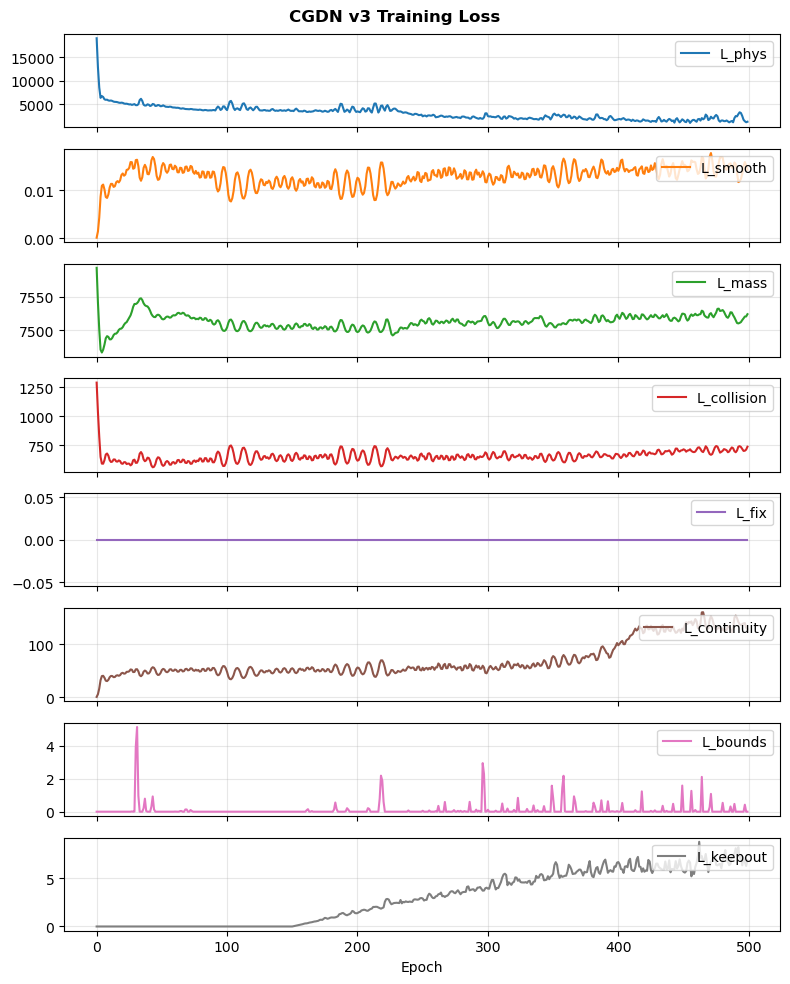

In [6]:
## Training
## ─────────────────────────────────────────────────────────────

if __name__ == "__main__":
    ## ── Model Configuration ──
    in_channels      = 8     ## [x, y, fix_x, fix_y, part_id, section_id, t, fy]
    hidden_channels  = 128
    num_layers       = 4
    heads            = 4
    edge_feature_dim = 4
    learning_rate    = 1e-3
    weight_decay     = 1e-4
    max_epochs       = 500
    target_mps       = {0:  406034, # [0, 1,    2]
                        1:  380000, # [0, 1,    2]
                        2:  370000, # [0, 1,    2]
                        3:  365000, # [0, 1,    2]
                        4:  360000, # [0, 1,    2]
                        5:  355000, # [0, 1,    2]
                        6:  350000, # [0, 1,    2]
                        7:  345000, # [0, 1,    2]
                        8:  520000, # [0, 1, 3, 2]
                        9:  510000, # [0, 1, 3, 2]
                        10: 500000, # [0, 1, 3, 2]
                        11: 490000, # [0, 1, 3, 2]
                        12: 400000, # [0,    3, 2]
                        13: 380000, # [0,    3, 2]
                        14: 360000, # [0,    3, 2]
                        15: 400000, # [0, 4, 3, 2]
                        16: 446173} # [0, 4, 3, 2]
    target_area      = 0
    warmup_ratio     = 0.3
    weights          = {'w_phys': 0.001, 
                        'w_smooth': 0.0001, 
                        'w_mass': 0.00000001,
                        'w_collision': 0.001, 
                        'w_fix': 1.0, 
                        'w_continuity': 0.0001,
                        'w_bounds': 1.0,
                        'w_keepout': 1.0}
    
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = CGDN(in_channels=in_channels,
                 hidden_channels=hidden_channels,
                 num_layers=num_layers,
                 heads=heads,
                 edge_dim=edge_feature_dim).to(device)
    optimizer = optim.AdamW(model.parameters(), 
                            lr=learning_rate, 
                            weight_decay=weight_decay)
    data = Data(x=x, edge_index=edge_index, edge_attr=edge_attr,
                join_pairs=join_pairs).to(device)

    ## ── Training ──
    (loss_hist, info, l_phys_hist, l_smooth_hist, initial_area, area_hist, l_mass_hist, 
     l_collision_hist, l_fix_hist, l_continuity_hist, l_bounds_hist, l_keepout_hist
     ) = training(model, data, optimizer, target_mps, target_area, bounds, keepout, max_epochs, 
                  weights=weights, warmup_ratio=warmup_ratio)

    ## ── Loss 시각화 ──
    epochs = list(range(max_epochs))
    labels = ['L_phys', 'L_smooth', 'L_mass', 'L_collision', 'L_fix', 'L_continuity', 'L_bounds', 'L_keepout']
    fig, axes = plt.subplots(len(labels), 1, figsize=(8, 10), sharex=True)
    hists  = [l_phys_hist, l_smooth_hist, l_mass_hist, l_collision_hist,
               l_fix_hist, l_continuity_hist, l_bounds_hist, l_keepout_hist]

    for ax, lbl, hist, c in zip(axes, labels, hists, [f'C{i}' for i in range(len(labels))]):
        ax.plot(epochs, hist, label=lbl, color=c)
        ax.grid(True, alpha=0.3)
        ax.legend(loc='upper right')

    axes[-1].set_xlabel('Epoch')
    plt.suptitle('CGDN v3 Training Loss', fontweight='bold')
    plt.tight_layout()
    plt.show()


Initial and Final Mp (N·mm)
  Section     |    initial |  predicted |     target |  % error
──────────────|────────────|────────────|────────────|──────────
  Section 16  |     459000 |     459000 |     446173 |    2.87%
  Section 15  |     530053 |     403884 |     400000 |    0.97%
  Section 14  |     364500 |     358972 |     360000 |    0.29%
  Section 13  |     364500 |     374401 |     380000 |    1.47%
  Section 12  |     364500 |     401462 |     400000 |    0.37%
  Section 11  |     579048 |     498537 |     490000 |    1.74%
  Section 10  |     579048 |     505393 |     500000 |    1.08%
  Section  9  |     579048 |     511474 |     510000 |    0.29%
  Section  8  |     579048 |     522290 |     520000 |    0.44%
  Section  7  |     471447 |     343597 |     345000 |    0.41%
  Section  6  |     471447 |     351944 |     350000 |    0.56%
  Section  5  |     471447 |     362598 |     355000 |    2.14%
  Section  4  |     471447 |     365689 |     360000 |    1.58%
  Section  

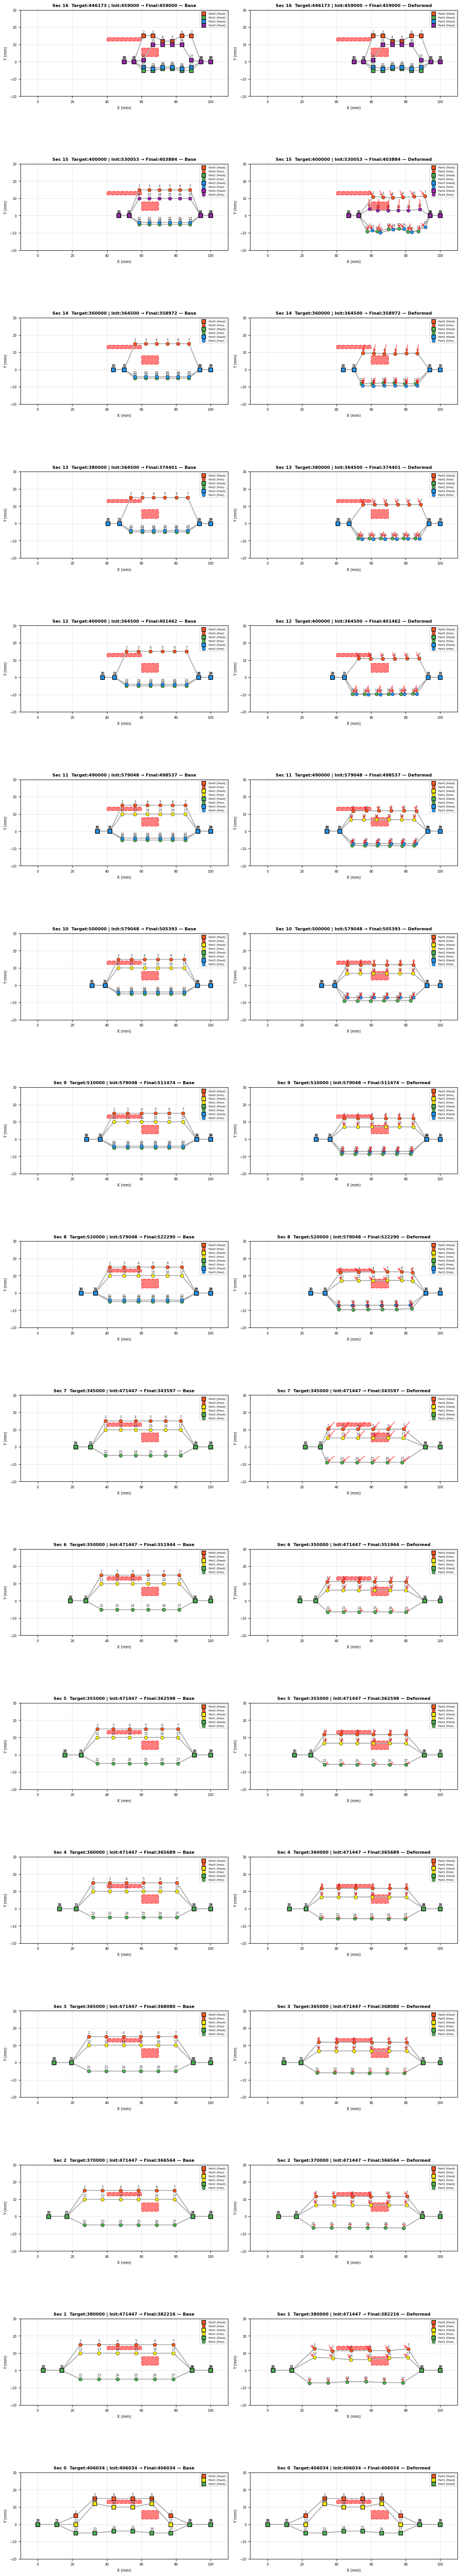

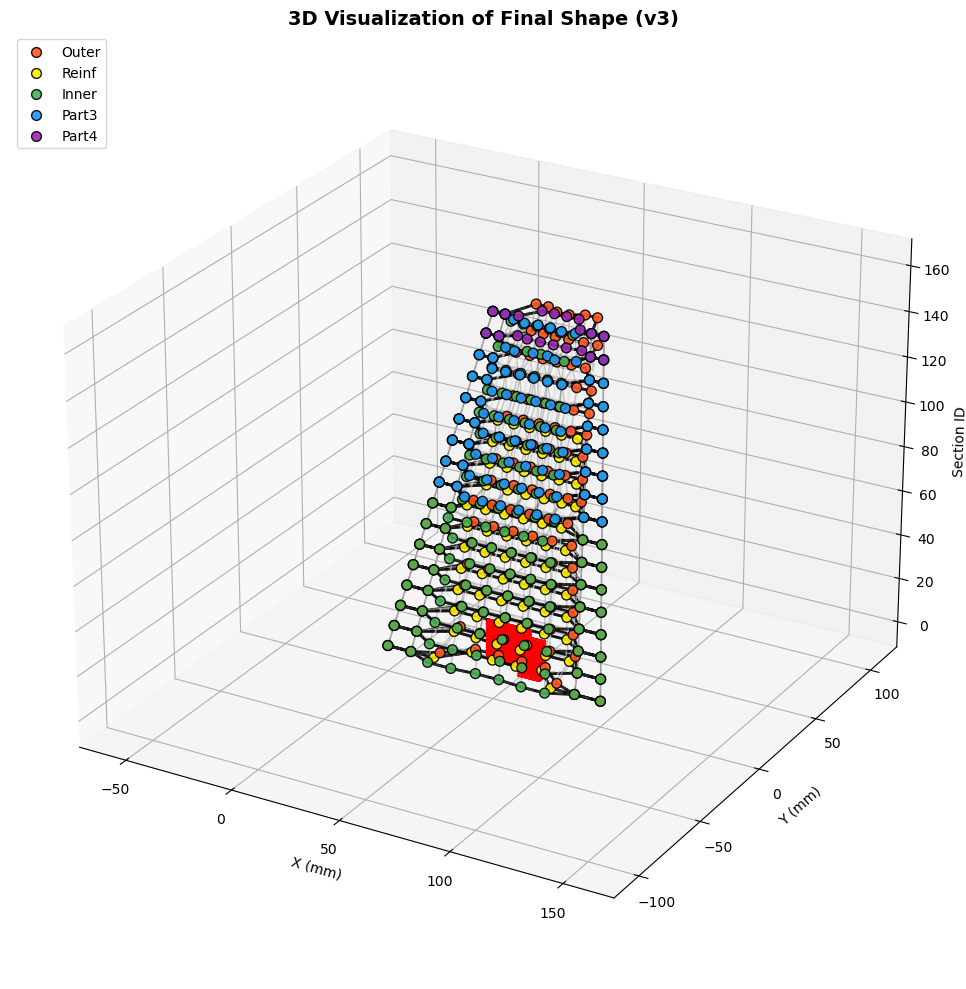

new coords: tensor([[  0.0000,   0.0000],
        [ 11.0000,   0.0000],
        [ 22.0000,   5.0000],
        ...,
        [ 88.8900,   1.0000],
        [ 94.4400,   0.0000],
        [100.0000,   0.0000]])


In [7]:
## 2D Section-by-Section Visualization (v3: 열 인덱스 업데이트)
## ─────────────────────────────────────────────────────────────

## section_offsets, num_nodes_in_section 동적 계산 (parts_in_sections 기반)
num_nodes_in_section = [len(parts_in_sections[s]) * num_nodes for s in range(num_sections)]
section_offsets      = [int(sum(num_nodes_in_section[:s])) for s in range(num_sections)]

print(f"{'=' * 70}")
print(f"Initial and Final Mp (N·mm)")
print(f"{'Section':>9}     | {'initial':>10} | {'predicted':>10} | {'target':>10} | {'% error':>8}")
print(f"{'─' * 14}|{'─' * 12}|{'─' * 12}|{'─' * 12}|{'─' * 10}")
for i in range(num_sections - 1, -1, -1):
    s = section_offsets[i]
    e = s + num_nodes_in_section[i]
    init_mp = calculate_mpl(data.x[s:e, :2], data.x[s:e, 6:7], data.x[s:e, 7:8], None)
    print(f"  Section {i:2d}  | {init_mp:>10.0f} | {info['pred_mp'][i]:>10.0f} | {target_mps[i]:>10.0f} | {100 * abs(info['pred_mp'][i] - target_mps[i]) / target_mps[i]:>7.2f}%")
print("=" * 70)
print(f"Initial Area : {initial_area:.0f} mm²")
print(f"Final Area   : {info['area']:.0f} mm²")
print("=" * 70)
print(f"Bounds and Keepout")
# compute global bounds across all sections
new_np = info['new_coords'].cpu().numpy()
xcoords = new_np[:, 0]
ycoords = new_np[:, 1]
global_xmin = min(b[0] for b in bounds.values())
global_xmax = max(b[1] for b in bounds.values())
global_ymin = min(b[2] for b in bounds.values())
global_ymax = max(b[3] for b in bounds.values())
if xcoords.min() < global_xmin or xcoords.max() > global_xmax:
    print("Boundary violation detected in X-axis!")
    print(f"  x range: [{xcoords.min():.2f}, {xcoords.max():.2f}] vs global [{global_xmin}, {global_xmax}]")
else:
    print("  No boundary violation in X-axis.")
if ycoords.min() < global_ymin or ycoords.max() > global_ymax:
    print("Boundary violation detected in Y-axis!")
    print(f"  y range: [{ycoords.min():.2f}, {ycoords.max():.2f}] vs global [{global_ymin}, {global_ymax}]")
else:
    print("  No boundary violation in Y-axis.")
# check keepout zones per section and list all violating nodes
violations = []
# get part and section ids from original data (safe on CPU)
part_ids   = data.x[:, 4].detach().cpu().numpy().astype(int)
section_ids = data.x[:, 5].detach().cpu().numpy().astype(int)

for sec_id, kz_list in keepout.items():
    for kz in kz_list:
        kx_min, kx_max, ky_min, ky_max = kz
        sec_mask = (section_ids == int(sec_id))
        mask = sec_mask & ((xcoords > kx_min) & (xcoords < kx_max) &
                           (ycoords > ky_min) & (ycoords < ky_max))
        idxs = np.where(mask)[0]
        for i in idxs:
            violations.append((int(section_ids[i]), int(part_ids[i]), int(i), float(xcoords[i]), float(ycoords[i])))
if len(violations) == 0:
    print("  No keepout violations detected.")
else:
    print(f"  Found {len(violations)} keepout-violating nodes:")
    print(f"  {'section':>7}  {'part':>4}  {'node_id':>7}    {'x':>8}    {'y':>8}")
    for s, p, nid, xv, yv in violations:
        print(f"  {s:7d}  {p:4d}  {nid:7d}    {xv:8.3f}    {yv:8.3f}")
print("=" * 70)

## ── 2D subplot 시각화 (모든 섹션 하나의 figure에, section 16 위 / section 0 아래) ──

def draw_section_on_axes(ax_base, ax_def, coords, edge_index, x_features, title="",
                          deformed_coords=None, section_start=0, keepout=None, global_ylim=None):
    """Draw base and deformed cross-section onto provided axes (no new figure)."""
    section_end = section_start + coords.shape[0]

    ei_mask = (edge_index[0] >= section_start) & (edge_index[0] < section_end) & \
              (edge_index[1] >= section_start) & (edge_index[1] < section_end)
    local_edge_index = edge_index[:, ei_mask] - section_start

    sec_id    = int(x_features[0, 5].item())
    fix_x     = x_features[:, 2].cpu().numpy() > 0
    fix_y     = x_features[:, 3].cpu().numpy() > 0
    is_fixed  = fix_x | fix_y
    p_ids     = x_features[:, 4].cpu().numpy().astype(int)
    coords_np = coords.cpu().detach().numpy()
    ei        = local_edge_index.cpu().numpy()

    color_map = {0: '#FF5722', 1: '#FFEE00', 2: '#4CAF50', 3: '#2196F3', 4: '#9C27B0'}
    marker_map = {True: 's', False: 'o'}
    label_map  = {True: 'Fixed', False: 'Free'}
    part_name  = {0: 'Part0', 1: 'Part1', 2: 'Part2', 3: 'Part3', 4: 'Part4'}

    def _draw(ax, pts, subtitle):
        for j in range(ei.shape[1]):
            sd, dd = ei[0, j], ei[1, j]
            ax.plot([pts[sd, 0], pts[dd, 0]], [pts[sd, 1], pts[dd, 1]],
                    color='#b0b0b0', linewidth=1.5, zorder=1)

        if keepout is not None and sec_id in keepout:
            from matplotlib.patches import Rectangle
            for kz in keepout[sec_id]:
                kx_min, kx_max, ky_min, ky_max = kz
                rect = Rectangle((kx_min, ky_min), kx_max - kx_min, ky_max - ky_min,
                                  linewidth=1.5, edgecolor='red', linestyle='--',
                                  facecolor='red', alpha=0.5, zorder=0)
                ax.add_patch(rect)

        for lid, color in color_map.items():
            for fix in [True, False]:
                mask_node = (p_ids == lid) & (is_fixed == fix)
                if not mask_node.any():
                    continue
                lbl = f'{part_name.get(lid, f"Part{lid}")} ({label_map[fix]})'
                ax.scatter(pts[mask_node, 0], pts[mask_node, 1],
                           c=color, marker=marker_map[fix],
                           s=60 if fix else 40, edgecolors='k',
                           linewidths=1.0 if fix else 0.5,
                           zorder=3, label=lbl)

        for j in range(len(pts)):
            ax.annotate(str(j), (pts[j, 0], pts[j, 1]),
                        fontsize=6, ha='center', va='bottom',
                        xytext=(0, 4), textcoords='offset points', color='#333333')

        ax.set_title(subtitle, fontsize=8, fontweight='bold')
        ax.set_xlabel('X (mm)', fontsize=7)
        ax.set_ylabel('Y (mm)', fontsize=7)
        ax.tick_params(labelsize=6)
        ax.set_aspect('equal')
        ax.grid(True, alpha=0.3)
        # X축은 각 섹션의 bounds로 설정
        ax.set_xlim(bounds[sec_id][0] - 10, bounds[sec_id][1] + 10)
        # Y축은 전체 섹션에서 동일한 범위 사용 (keepout 비교 용이)
        if global_ylim is not None:
            ax.set_ylim(global_ylim[0], global_ylim[1])
        else:
            ax.set_ylim(bounds[sec_id][2] - 10, bounds[sec_id][3] + 10)
        handles_l, labels_l = ax.get_legend_handles_labels()
        by_label = dict(zip(labels_l, handles_l))
        ax.legend(by_label.values(), by_label.keys(), fontsize=5, loc='upper right')

    _draw(ax_base, coords_np, f'{title} — Base')

    if deformed_coords is not None and ax_def is not None:
        def_np = deformed_coords.cpu().detach().numpy()
        _draw(ax_def, def_np, f'{title} — Deformed')
        for j in range(len(coords_np)):
            dx = def_np[j, 0] - coords_np[j, 0]
            dy = def_np[j, 1] - coords_np[j, 1]
            if np.sqrt(dx**2 + dy**2) > 1e-3:
                ax_def.annotate('',
                    xy=(def_np[j, 0], def_np[j, 1]),
                    xytext=(coords_np[j, 0], coords_np[j, 1]),
                    arrowprops=dict(arrowstyle='->', color='red', lw=1.2, alpha=0.7))
    
## section 16 → row 0 (top), section 0 → row 16 (bottom)
section_order = list(range(num_sections - 1, -1, -1))   # [16, 15, ..., 0]
n_rows = len(section_order)

# 전체 섹션의 Y축 범위를 미리 계산 (keepout 비교 용이하게 통일)
global_ymin = min(b[2] for b in bounds.values())
global_ymax = max(b[3] for b in bounds.values())
global_ylim = (global_ymin - 10, global_ymax + 10)

fig, axes = plt.subplots(n_rows, 2, figsize=(12, 4 * n_rows))
# fig.suptitle('B-Pillar Cross Sections — All Sections (Top=Sec16, Bottom=Sec0)',
#              fontsize=14, fontweight='bold')

for row_idx, i in enumerate(section_order):
    s = section_offsets[i]
    e = s + num_nodes_in_section[i]

    base_coords_sec  = data.x[s:e, :2]
    deformed_sec     = info['new_coords'][s:e]
    section_features = data.x[s:e, :]

    target_mp_val  = target_mps[i]
    initial_mp_val = calculate_mpl(base_coords_sec,
                                   section_features[:, 6:7],
                                   section_features[:, 7:8], None).item()
    final_mp_val   = info['pred_mp'][i]

    title_str = (f'Sec {i}  Target:{target_mp_val:.0f} | '
                 f'Init:{initial_mp_val:.0f} → Final:{final_mp_val:.0f}')

    draw_section_on_axes(
        ax_base=axes[row_idx, 0],
        ax_def=axes[row_idx, 1],
        coords=base_coords_sec,
        edge_index=data.edge_index,
        x_features=section_features,
        title=title_str,
        deformed_coords=deformed_sec,
        section_start=s,
        keepout=keepout,
        global_ylim=global_ylim,
    )

plt.tight_layout()
plt.show()

## ─────────────────────────────────────────────────────────────
## 3D Visualization (v3: 열 인덱스 업데이트)
## ─────────────────────────────────────────────────────────────
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
def visualize_3d_final_shape(base_coords, new_coords, edge_index, part_ids, section_ids, edge_attr, bounds=None, keepout=None):
    fig = plt.figure(figsize=(12, 10))
    ax = fig.add_subplot(111, projection='3d')

    base_np      = base_coords.cpu().numpy()
    deformed_np  = new_coords.cpu().detach().numpy()
    edge_np      = edge_index.cpu().numpy()
    part_np      = part_ids.cpu().numpy()
    section_np   = section_ids.cpu().numpy()
    edge_attr_np = edge_attr.cpu().numpy()

    color_map = {0: '#FF5722', 1: '#FFEE00', 2: '#4CAF50', 3: '#2196F3', 4: '#9C27B0'}

    if keepout is not None:
        for sec_id, kz_list in keepout.items():
            for kz in kz_list:
                kx_min, kx_max, ky_min, ky_max = kz
                z_min, z_max = sec_id - 0.01, sec_id + 0.01
                vertices = [
                    [kx_min, ky_min, z_min], [kx_max, ky_min, z_min],
                    [kx_max, ky_max, z_min], [kx_min, ky_max, z_min],
                    [kx_min, ky_min, z_max], [kx_max, ky_min, z_max],
                    [kx_max, ky_max, z_max], [kx_min, ky_max, z_max],
                ]
                faces = [
                    [vertices[0], vertices[1], vertices[2], vertices[3]],
                    [vertices[4], vertices[5], vertices[6], vertices[7]],
                    [vertices[0], vertices[1], vertices[5], vertices[4]],
                    [vertices[2], vertices[3], vertices[7], vertices[6]],
                    [vertices[1], vertices[2], vertices[6], vertices[5]],
                    [vertices[3], vertices[0], vertices[4], vertices[7]],
                ]
                ax.add_collection3d(Poly3DCollection(faces, facecolors='red', edgecolors='r', linewidths=1, alpha=0.3))

    for i in range(edge_np.shape[1]):
        u, v = edge_np[:, i]
        xs_base = [base_np[u, 0], base_np[v, 0]]
        ys_base = [base_np[u, 1], base_np[v, 1]]
        zs_base = [section_np[u]*10, section_np[v]*10]
        xs_def  = [deformed_np[u, 0], deformed_np[v, 0]]
        ys_def  = [deformed_np[u, 1], deformed_np[v, 1]]
        zs_def  = [section_np[u]*10, section_np[v]*10]
        edge_type = edge_attr_np[i, 3]
        if edge_type == 0.0:
            ax.plot(xs_base, ys_base, zs_base, color='#BBBBBB', linestyle='--', linewidth=1.5, alpha=0.7)
            ax.plot(xs_def,  ys_def,  zs_def,  color='k',       linestyle='-',  linewidth=2.0, alpha=0.7)
        elif edge_type == 1.0:
            ax.plot(xs_base, ys_base, zs_base, color='#DDDDDD', linestyle='--', linewidth=1.0, alpha=0.4)
            ax.plot(xs_def,  ys_def,  zs_def,  color='k',       linestyle='-',  linewidth=1.0, alpha=0.1)

    for part_id in color_map.keys():
        mask = (part_np == part_id)
        if not mask.any():
            continue
        label = {0: 'Outer', 1: 'Reinf', 2: 'Inner', 3: 'Part3', 4: 'Part4'}.get(part_id, f'Part{part_id}')
        ax.scatter(deformed_np[mask, 0], deformed_np[mask, 1], section_np[mask]*10,
                   c=color_map[part_id], label=label,
                   s=50, edgecolors='k', alpha=0.9)

    ax.set_xlabel('X (mm)')
    ax.set_ylabel('Y (mm)')
    ax.set_zlabel('Section ID')
    ax.set_title('3D Visualization of Final Shape (v3)', fontsize=14, fontweight='bold')
    # ax.set_zticks(list(range(num_sections)*10))
    ax.view_init(elev=25, azim=-60)
    ax.legend(loc='upper left', fontsize=10)
    plt.axis('equal')
    plt.tight_layout()
    plt.show()

visualize_3d_final_shape(
    base_coords=data.x[:, :2],
    new_coords=info['new_coords'],
    edge_index=data.edge_index,
    part_ids=data.x[:, 4],        ## v3: part_id → col 4
    section_ids=data.x[:, 5],     ## v3: section_id → col 5
    edge_attr=data.edge_attr,
    keepout=keepout)

print("new coords:", info['new_coords'])




In [8]:
import plotly.graph_objects as go
import numpy as np

def visualize_bpillar_plotly(x_tensor, edge_index_tensor, edge_attr_tensor, num_sections):
    # 텐서를 Numpy 배열로 변환
    x_np = x_tensor.cpu().numpy()
    ei_np = edge_index_tensor.cpu().numpy()
    ea_np = edge_attr_tensor.cpu().numpy()

    # 파트별 색상 맵 (Plotly용 Hex 컬러)
    color_map = {0: '#FF5722', 1: '#FFEE00', 2: '#4CAF50', 3: '#2196F3', 4: '#9C27B0'}
    part_names = {0: 'Part0', 1: 'Part1', 2: 'Part2', 3: 'Part3', 4: 'Part4'}

    fig = go.Figure()

    # ---------------------------------------------------------
    # 1. 엣지(Edge) 그리기 (None-interleaving 기법 적용)
    # ---------------------------------------------------------
    def add_edges(edge_type_val, color, width, dash_style, name):
        mask = (ea_np[:, 3] == edge_type_val)
        edges = ei_np[:, mask]
        
        # 선을 한 번에 그리기 위해 [x1, x2, None, x3, x4, None...] 형태로 리스트 구성
        x_lines, y_lines, z_lines = [], [], []
        for i in range(edges.shape[1]):
            u, v = edges[0, i], edges[1, i]
            x_lines.extend([x_np[u, 0], x_np[v, 0], None])
            y_lines.extend([x_np[u, 1], x_np[v, 1], None])
            z_lines.extend([x_np[u, 5], x_np[v, 5], None])
            
        if x_lines:  # 엣지가 존재할 경우만 trace 추가
            fig.add_trace(go.Scatter3d(
                x=x_lines, y=y_lines, z=z_lines,
                mode='lines',
                line=dict(color=color, width=width, dash=dash_style),
                hoverinfo='none',  # 엣지에는 마우스 오버 끄기 (노드에만 집중)
                name=name,
                showlegend=True
            ))

    # 엣지 타입별 추가
    add_edges(edge_type_val=0.0, color='#AAAAAA', width=2, dash_style='solid', name='Intra-section (가로)')
    add_edges(edge_type_val=1.0, color='#CCCCCC', width=1, dash_style='dash',  name='Inter-section (세로)')
    add_edges(edge_type_val=2.0, color='#FF0000', width=3, dash_style='dot',   name='Flange Join (결합)')

    # ---------------------------------------------------------
    # 2. 노드(Node) 그리기 (Part 및 Fixed/Free 상태별 분리)
    # ---------------------------------------------------------
    for part_id, color in color_map.items():
        is_fixed = (x_np[:, 2] > 0) | (x_np[:, 3] > 0)
        
        mask_free = (x_np[:, 4] == part_id) & ~is_fixed
        mask_fixed = (x_np[:, 4] == part_id) & is_fixed
        
        p_name = part_names.get(part_id, f'Part {part_id}')
        
        # Free 노드 (원형)
        if mask_free.any():
            fig.add_trace(go.Scatter3d(
                x=x_np[mask_free, 0], y=x_np[mask_free, 1], z=x_np[mask_free, 5],
                mode='markers',
                name=f'{p_name} (Free)',
                marker=dict(size=4, color=color, symbol='circle',
                            line=dict(color='black', width=1), opacity=0.9),
                hovertemplate=f'<b>{p_name}</b><br>X: %{{x:.2f}}<br>Y: %{{y:.2f}}<br>Section(Z): %{{z}}<extra></extra>'
            ))
            
        # Fixed 노드 (크고 네모난 마커)
        if mask_fixed.any():
            fig.add_trace(go.Scatter3d(
                x=x_np[mask_fixed, 0], y=x_np[mask_fixed, 1], z=x_np[mask_fixed, 5],
                mode='markers',
                name=f'{p_name} (Fixed)',
                marker=dict(size=6, color=color, symbol='square',
                            line=dict(color='black', width=2), opacity=1.0),
                hovertemplate=f'<b>{p_name} [FIXED]</b><br>X: %{{x:.2f}}<br>Y: %{{y:.2f}}<br>Section(Z): %{{z}}<extra></extra>'
            ))

    # ---------------------------------------------------------
    # 3. X-Y 축 범위 계산 (비율 맞추기)
    # ---------------------------------------------------------
    global_xmin, global_xmax = np.min(x_np[:, 0]), np.max(x_np[:, 0])
    global_ymin, global_ymax = np.min(x_np[:, 1]), np.max(x_np[:, 1])
    
    # X, Y 범위를 동일하게 맞추기
    x_range = global_xmax - global_xmin
    y_range = global_ymax - global_ymin
    max_range = max(x_range, y_range)
    
    x_center = (global_xmin + global_xmax) / 2
    y_center = (global_ymin + global_ymax) / 2
    
    x_axis_range = [x_center - max_range / 2, x_center + max_range / 2]
    y_axis_range = [y_center - max_range / 2, y_center + max_range / 2]

    # ---------------------------------------------------------
    # 4. 레이아웃(Layout) 및 카메라 설정
    # ---------------------------------------------------------
    fig.update_layout(
        title="<b>3D B-Pillar Graph (Base)</b>",
        scene=dict(
            xaxis_title='X (mm)',
            yaxis_title='Y (mm)',
            zaxis_title='Section ID',
            xaxis=dict(range=x_axis_range),
            yaxis=dict(range=y_axis_range),
            zaxis=dict(tickmode='linear', tick0=0, dtick=1), # Z축 눈금을 1단위로 표시
            aspectmode='manual',
            aspectratio=dict(x=1, y=1, z=1.5),  # Z축(높이) 비율을 약간 길게 설정
            camera=dict(
                eye=dict(x=-0.8, y=-1.0, z=0.8),  # 초기 카메라 앵글
                projection=dict(type='orthographic')  # 원근 왜곡 제거 (평행 투영)
                ),
        ),
        width=1000,
        height=800,
        legend=dict(
            x=1.05, y=0.5,
            bgcolor='rgba(255, 255, 255, 0.8)',
            bordercolor='Black',
            borderwidth=1
        ),
        margin=dict(l=0, r=0, b=0, t=50) # 여백 최소화
    )
    

    fig.show()

# 함수 실행 (앞서 생성하신 x, edge_index, edge_attr 텐서를 그대로 넣으시면 됩니다)
visualize_bpillar_plotly(x, edge_index, edge_attr, num_sections)

print("📌 마우스 조작 방법:")
print("   • 마우스 좌클릭 드래그: 3D 회전")
print("   • 마우스 우클릭 드래그: 이동 (Pan)")
print("   • 마우스 휠: 확대/축소") 
print("   • 점 위에 마우스 올리기: 좌표 및 파트 상세 정보 표시")
print("   • 우측 범례(Legend) 클릭: 해당 파트/엣지 표시 또는 숨김")

📌 마우스 조작 방법:
   • 마우스 좌클릭 드래그: 3D 회전
   • 마우스 우클릭 드래그: 이동 (Pan)
   • 마우스 휠: 확대/축소
   • 점 위에 마우스 올리기: 좌표 및 파트 상세 정보 표시
   • 우측 범례(Legend) 클릭: 해당 파트/엣지 표시 또는 숨김


In [9]:
import plotly.graph_objects as go
import numpy as np

def visualize_bpillar_plotly_deformed(x_tensor, deformed_x_tensor, edge_index_tensor, edge_attr_tensor, num_sections):
    # 텐서를 Numpy 배열로 변환
    x_np = x_tensor.cpu().numpy()
    deformed_x_np = deformed_x_tensor.cpu().numpy()
    ei_np = edge_index_tensor.cpu().numpy()
    ea_np = edge_attr_tensor.cpu().numpy()

    # 파트별 색상 맵 (Plotly용 Hex 컬러)
    color_map = {0: '#FF5722', 1: '#FFEE00', 2: '#4CAF50', 3: '#2196F3', 4: '#9C27B0'}
    part_names = {0: 'Part0', 1: 'Part1', 2: 'Part2', 3: 'Part3', 4: 'Part4'}

    fig = go.Figure()

    # ---------------------------------------------------------
    # 1. 엣지(Edge) 그리기 (None-interleaving 기법 적용)
    # ---------------------------------------------------------
    def add_edges(edge_type_val, color, width, dash_style, name):
        mask = (ea_np[:, 3] == edge_type_val)
        edges = ei_np[:, mask]
        
        # 선을 한 번에 그리기 위해 [x1, x2, None, x3, x4, None...] 형태로 리스트 구성
        x_lines, y_lines, z_lines = [], [], []
        for i in range(edges.shape[1]):
            u, v = edges[0, i], edges[1, i]
            x_lines.extend([deformed_x_np[u, 0], deformed_x_np[v, 0], None])
            y_lines.extend([deformed_x_np[u, 1], deformed_x_np[v, 1], None])
            z_lines.extend([x_np[u, 5], x_np[v, 5], None])
            
        if x_lines:  # 엣지가 존재할 경우만 trace 추가
            fig.add_trace(go.Scatter3d(
                x=x_lines, y=y_lines, z=z_lines,
                mode='lines',
                line=dict(color=color, width=width, dash=dash_style),
                hoverinfo='none',  # 엣지에는 마우스 오버 끄기 (노드에만 집중)
                name=name,
                showlegend=True
            ))

    # 엣지 타입별 추가
    add_edges(edge_type_val=0.0, color='#AAAAAA', width=2, dash_style='solid', name='Intra-section (가로)')
    add_edges(edge_type_val=1.0, color='#CCCCCC', width=1, dash_style='dash',  name='Inter-section (세로)')
    add_edges(edge_type_val=2.0, color='#FF0000', width=3, dash_style='dot',   name='Flange Join (결합)')

    # ---------------------------------------------------------
    # 2. 노드(Node) 그리기 (Part 및 Fixed/Free 상태별 분리)
    # ---------------------------------------------------------
    for part_id, color in color_map.items():
        is_fixed = (x_np[:, 2] > 0) | (x_np[:, 3] > 0)
        
        mask_free = (x_np[:, 4] == part_id) & ~is_fixed
        mask_fixed = (x_np[:, 4] == part_id) & is_fixed
        
        p_name = part_names.get(part_id, f'Part {part_id}')
        
        # Free 노드 (원형)
        if mask_free.any():
            fig.add_trace(go.Scatter3d(
                x=deformed_x_np[mask_free, 0], y=deformed_x_np[mask_free, 1], z=x_np[mask_free, 5],
                mode='markers',
                name=f'{p_name} (Free)',
                marker=dict(size=4, color=color, symbol='circle',
                            line=dict(color='black', width=1), opacity=0.9),
                hovertemplate=f'<b>{p_name}</b><br>X: %{{x:.2f}}<br>Y: %{{y:.2f}}<br>Section(Z): %{{z}}<extra></extra>'
            ))
            
        # Fixed 노드 (크고 네모난 마커)
        if mask_fixed.any():
            fig.add_trace(go.Scatter3d(
                x=deformed_x_np[mask_fixed, 0], y=deformed_x_np[mask_fixed, 1], z=x_np[mask_fixed, 5],
                mode='markers',
                name=f'{p_name} (Fixed)',
                marker=dict(size=6, color=color, symbol='square',
                            line=dict(color='black', width=2), opacity=1.0),
                hovertemplate=f'<b>{p_name} [FIXED]</b><br>X: %{{x:.2f}}<br>Y: %{{y:.2f}}<br>Section(Z): %{{z}}<extra></extra>'
            ))

    # ---------------------------------------------------------
    # 3. X-Y 축 범위 계산 (비율 맞추기)
    # ---------------------------------------------------------
    global_xmin, global_xmax = np.min(deformed_x_np[:, 0]), np.max(deformed_x_np[:, 0])
    global_ymin, global_ymax = np.min(deformed_x_np[:, 1]), np.max(deformed_x_np[:, 1])
    
    # X, Y 범위를 동일하게 맞추기
    x_range = global_xmax - global_xmin
    y_range = global_ymax - global_ymin
    max_range = max(x_range, y_range)
    
    x_center = (global_xmin + global_xmax) / 2
    y_center = (global_ymin + global_ymax) / 2
    
    x_axis_range = [x_center - max_range / 2, x_center + max_range / 2]
    y_axis_range = [y_center - max_range / 2, y_center + max_range / 2]

    # ---------------------------------------------------------
    # 4. 레이아웃(Layout) 및 카메라 설정
    # ---------------------------------------------------------
    fig.update_layout(
        title="<b>3D B-Pillar Graph (Deformed)</b>",
        scene=dict(
            xaxis_title='X (mm)',
            yaxis_title='Y (mm)',
            zaxis_title='Section ID',
            xaxis=dict(range=x_axis_range),
            yaxis=dict(range=y_axis_range),
            zaxis=dict(tickmode='linear', tick0=0, dtick=1), # Z축 눈금을 1단위로 표시
            aspectmode='manual',
            aspectratio=dict(x=1, y=1, z=1.5),  # Z축(높이) 비율을 약간 길게 설정
            camera=dict(
                eye=dict(x=-0.8, y=-1.0, z=0.8),  # 초기 카메라 앵글
                projection=dict(type='orthographic')  # 원근 왜곡 제거 (평행 투영)
            )
        ),
        width=1000,
        height=800,
        legend=dict(
            x=1.05, y=0.5,
            bgcolor='rgba(255, 255, 255, 0.8)',
            bordercolor='Black',
            borderwidth=1
        ),
        margin=dict(l=0, r=0, b=0, t=50) # 여백 최소화
    )

    fig.show()

# 함수 실행 (앞서 생성하신 x, edge_index, edge_attr 텐서를 그대로 넣으시면 됩니다)
visualize_bpillar_plotly_deformed(x, info['new_coords'], edge_index, edge_attr, num_sections)

print("📌 마우스 조작 방법:")
print("   • 마우스 좌클릭 드래그: 3D 회전")
print("   • 마우스 우클릭 드래그: 이동 (Pan)")
print("   • 마우스 휠: 확대/축소") 
print("   • 점 위에 마우스 올리기: 좌표 및 파트 상세 정보 표시")
print("   • 우측 범례(Legend) 클릭: 해당 파트/엣지 표시 또는 숨김")


📌 마우스 조작 방법:
   • 마우스 좌클릭 드래그: 3D 회전
   • 마우스 우클릭 드래그: 이동 (Pan)
   • 마우스 휠: 확대/축소
   • 점 위에 마우스 올리기: 좌표 및 파트 상세 정보 표시
   • 우측 범례(Legend) 클릭: 해당 파트/엣지 표시 또는 숨김


In [10]:
# 2. 메타데이터 생성: (section 번호, part 번호, 노드 인덱스)
current_metadata = []
for sec in range(17):
    for part in sorted(parts_in_sections[sec]):
        for node_idx in range(num_nodes):
            current_metadata.append((sec, part, node_idx))

# 3. 흩어진 텐서 리스트와 메타데이터 짝짓기
paired_data = list(zip(current_metadata, info['new_coords']))

# 4. 원하는 기준으로 정렬
# x[0][1]: part (1순위)
# x[0][0]: section (2순위)
# x[0][2]: node index (3순위 - 10개 노드의 원래 순서 유지)
paired_data.sort(key=lambda x: (x[0][1], x[0][0], x[0][2]))

# 5. 정렬된 데이터에서 텐서만 다시 추출하여 하나의 2D 텐서 행렬로 병합
sorted_tensors = [data for meta, data in paired_data]
info['new_coords_sorted'] = torch.stack(sorted_tensors).cpu().numpy()

# 6. 각 part가 끝날 때마다 (0,0) 행 삽입
coords = info['new_coords_sorted']  # (570, 2)
sorted_metas = [meta for meta, _ in paired_data]

coords_list = []
prev_part = None
for i, meta in enumerate(sorted_metas):
    current_part = meta[1]
    if prev_part is not None and current_part != prev_part:
        coords_list.append(np.zeros((1, 2)))  # part 경계에 (0,0) 삽입
    coords_list.append(coords[i:i+1])
    prev_part = current_part
coords_list.append(np.zeros((1, 2)))  # 마지막 part 뒤에도 삽입
coords_with_zeros = np.vstack(coords_list)

## ----- Excel로 좌표 저장 (part 순서로 정렬 후 저장) -----
import pandas as pd
df = pd.DataFrame(coords_with_zeros, columns=['x', 'y'])
df.to_excel('deformed_coords.xlsx', index=False)
